# Sweden noise barriers — overview, cleaning & school matching

**Source.** Trafikverket's national noise-barrier inventory ("Bullerskydd"),
two separate products — road (*Bullerskydd - väg*) and rail (*Bullerskydd*) —
ordered from Lastkajen as GeoPackage exports in SWEREF99 TM (EPSG:3006).
Fetched with `python -m src.cli sweden data noise-barriers fetch --source
{highway,railway}` into `data/sweden/noise_barriers/raw/`, cleaned by
`noise_barriers/preprocess.py` into
`data/sweden/noise_barriers/processed/{road,rail}_noise_barriers.parquet`.

**Schools.** Skolverket's `Skolenhetsregistret`, geocoded by
`schools/preprocess.py` — the schools pipeline itself lives in
[`schools.ipynb`](schools.ipynb).

**This notebook**
1. loads both barrier layers (raw + processed) and documents their fields,
2. gives descriptives (currency, side, construction year, physical
   dimensions, geography) with a statewide map,
3. documents the cleaning `preprocess.py` already applies and verifies it
   live against the data, rather than trusting the module's docstring,
4. loads school points and reads the real point-distance match
   (`schools/assemble.py` algorithms 1–2) as a worked cross-check.

**Out of scope here**: the road-network-aware `same_route`/`same_side`
tiers (algorithms 3–5), the `same_side` data-provenance bug, and whether
the barrier's own `side` attribute could fix it — that's
`schools/assemble.py`'s network-matching logic, verified against real
persisted output in [`schools.ipynb`](schools.ipynb), not reprototyped
here.


In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import BLUE, GREEN, GREY, RED, np, pd, plt

import geopandas as gpd

DATA = ROOT / "data" / "sweden"
NOISE_BARRIERS = DATA / "noise_barriers"
SCHOOLS = DATA / "schools"

print("root:", ROOT)
print("raw:", sorted(p.name for p in (NOISE_BARRIERS / "raw").glob("*")))
print("processed:", sorted(p.name for p in (NOISE_BARRIERS / "processed").glob("*")))


root: /Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution
raw: ['highway_noise_barriers.gpkg', 'highway_noise_barriers_delivery_info.txt', 'highway_noise_barriers_license.txt', 'railway_noise_barriers.gpkg', 'railway_noise_barriers_delivery_info.txt', 'railway_noise_barriers_license.txt']
processed: ['rail_noise_barriers.parquet', 'road_noise_barriers.parquet']


## 1. Load


In [2]:

# NOTE: the raw filenames are misleading -- checked below (§1) and confirmed
# the *content* is swapped relative to what `--source highway`/`--source
# railway` implies. Loading by actual schema, not by trusting the name.
road_raw = gpd.read_file(NOISE_BARRIERS / "raw" / "railway_noise_barriers.gpkg")
rail_raw = gpd.read_file(NOISE_BARRIERS / "raw" / "highway_noise_barriers.gpkg")
for name, gdf in [("road (raw, from railway_noise_barriers.gpkg)", road_raw),
                   ("rail (raw, from highway_noise_barriers.gpkg)", rail_raw)]:
    print(f"{name}: {len(gdf):,} rows, {gdf.shape[1]} columns, CRS {gdf.crs.to_epsg()}, "
          f"geometry {gdf.geom_type.value_counts().to_dict()}")
print("\nroad-only raw columns present in each file (Materialtyp/Pa_bro are road-only, "
      "Bisobjektnr/Avstand_fr_sparmitt_m are rail-only):")
print("  railway_noise_barriers.gpkg has Materialtyp:", "Materialtyp" in road_raw.columns,
      "| has Bisobjektnr:", "Bisobjektnr" in road_raw.columns)
print("  highway_noise_barriers.gpkg has Materialtyp:", "Materialtyp" in rail_raw.columns,
      "| has Bisobjektnr:", "Bisobjektnr" in rail_raw.columns)

road_barriers = gpd.read_parquet(NOISE_BARRIERS / "processed" / "road_noise_barriers.parquet")
rail_barriers = gpd.read_parquet(NOISE_BARRIERS / "processed" / "rail_noise_barriers.parquet")
for name, gdf in [("road (processed)", road_barriers), ("rail (processed)", rail_barriers)]:
    print(f"{name}: {len(gdf):,} rows, {gdf.shape[1]} columns, is_current={gdf['is_current'].unique().tolist()}")


road (raw, from railway_noise_barriers.gpkg): 2,172 rows, 17 columns, CRS 3006, geometry {'LineString': 2172}
rail (raw, from highway_noise_barriers.gpkg): 1,829 rows, 26 columns, CRS 3006, geometry {'LineString': 1829}

road-only raw columns present in each file (Materialtyp/Pa_bro are road-only, Bisobjektnr/Avstand_fr_sparmitt_m are rail-only):
  railway_noise_barriers.gpkg has Materialtyp: True | has Bisobjektnr: False
  highway_noise_barriers.gpkg has Materialtyp: False | has Bisobjektnr: True


road (processed): 2,172 rows, 19 columns, is_current=[True]
rail (processed): 1,829 rows, 30 columns, is_current=[True]


**The raw filenames are wrong — confirmed above, not assumed.**
`highway_noise_barriers.gpkg` and `railway_noise_barriers.gpkg` (named
after the `--source {highway,railway}` flag passed to `noise-barriers
fetch`) are swapped relative to their actual content: `highway_*.gpkg`
carries the rail-only fields (`Bisobjektnr`, `Avstand_fr_sparmitt_m`, …)
and `railway_*.gpkg` carries the road-only ones (`Materialtyp`, `Pa_bro`).
Loaded above by schema, not filename. The two `*_delivery_info.txt`
sidecars agree with the content, not the filename — each one's own `Namn
på beställning` order name correctly names the *other* file's nominal kind
(e.g. `highway_noise_barriers_delivery_info.txt` names a "Rail" order),
consistent with the same swap happening at fetch time.


In [3]:
print("road_barriers['dataset_kind']:", road_barriers["dataset_kind"].unique().tolist(),
      "| has foundation_type:", "foundation_type" in road_barriers.columns,
      "| has bis_object_number:", "bis_object_number" in road_barriers.columns)
print("rail_barriers['dataset_kind']:", rail_barriers["dataset_kind"].unique().tolist(),
      "| has foundation_type:", "foundation_type" in rail_barriers.columns,
      "| has bis_object_number:", "bis_object_number" in rail_barriers.columns)


road_barriers['dataset_kind']: ['road'] | has foundation_type: True | has bis_object_number: False
rail_barriers['dataset_kind']: ['rail'] | has foundation_type: True | has bis_object_number: True


**The processed files are unaffected.** `noise_barriers/preprocess.py`
resolves its input bundle by searching every local `*_delivery_info.txt`'s
own *content* for the requested dataset name
(`find_local_noise_barrier_bundle`), not by filename — so whatever
dataset name was passed at preprocess time correctly found the right
GeoPackage regardless of the raw filename swap. `road_noise_barriers.parquet`
/`rail_noise_barriers.parquet` are correctly kind-labelled, confirmed by
the same schema check. The swap only matters for anyone loading the raw
`.gpkg` files directly by name, as this notebook's first attempt did.


## 2. Field dictionary

`preprocess.py` translates every raw Swedish column name (and several coded
values) to English. Pulled directly from the module rather than retyped
here, so this table can't drift from the real mapping.


In [4]:
from src.regions.sweden.sources.noise_barriers import preprocess as barrier_preprocess

rows = []
for sv, en in barrier_preprocess.COMMON_COLUMN_TRANSLATIONS.items():
    rows.append((en, sv, "both"))
for sv, en in barrier_preprocess.ROAD_COLUMN_TRANSLATIONS.items():
    rows.append((en, sv, "road"))
for sv, en in barrier_preprocess.RAIL_COLUMN_TRANSLATIONS.items():
    rows.append((en, sv, "rail"))
field_dict = pd.DataFrame(rows, columns=["field", "raw_swedish_name", "dataset"]).sort_values(["dataset", "field"])
field_dict


,field,raw_swedish_name,dataset
0,element_id,ELEMENT_ID,both
4,end_measure,END_MEASURE,both
5,extent_length_m,EXTENT_LENGTH,both
6,side,SIDE,both
3,start_measure,START_MEASURE,both
1,valid_from,VALID_FROM,both
2,valid_to,VALID_TO,both
16,absorbent,Absorbent,rail
30,barrier_type,Typ,rail
20,bis_object_number,Bisobjektnr,rail


Several of these fields are also value-translated (Swedish coded value →
English), not just renamed — `side`, `absorbent`, `owner`, `material_type`
/`barrier_type`, `foundation_type`, and the two maintenance fields. Two are
numeric fields carrying a "not recorded" sentinel instead of a real value:
`built_year`'s sentinel is `1900` for road and `0` for rail (already
handled in `preprocess.py`, confirmed live in §4 below).


## 3. Overview descriptives


### 3.1 Snapshot scope & currency


In [5]:
print("road is_current:", road_barriers["is_current"].value_counts(dropna=False).to_dict())
print("rail is_current:", rail_barriers["is_current"].value_counts(dropna=False).to_dict())
print("\nroad valid_from range:", road_barriers["valid_from"].min(), "..", road_barriers["valid_from"].max())
print("rail valid_from range:", rail_barriers["valid_from"].min(), "..", rail_barriers["valid_from"].max())


road is_current: {True: 2172}
rail is_current: {True: 1829}

road valid_from range: 2006-01-01 00:00:00 .. 2026-04-13 00:00:00
rail valid_from range: 2025-09-26 00:00:00 .. 2026-06-29 00:00:00


**Every row is `is_current=True`.** Unlike Florida's FDOT inventory (which
carries a `TYPE` lifecycle field — `RECOMMENDED`/`REMOVED`/`CONSTRUCTED`/…,
see [`florida/barriers.ipynb`](../florida/barriers.ipynb) §3.1), this export
is a live snapshot of currently-standing barriers only: no
recommended-but-unbuilt, no removed/retired records, no construction-status
field at all. There is nothing to filter here — every row this notebook
sees is already "physically present" by construction of the export itself.


### 3.2 Side


In [6]:
print("road side:\n", road_barriers["side"].value_counts(dropna=False), "\n")
print("rail side:\n", rail_barriers["side"].value_counts(dropna=False))


road side:
 side
right         1732
left           436
both_sides       4
Name: count, dtype: int64 

rail side:
 side
right         938
left          878
both_sides     10
center          3
Name: count, dtype: int64


Road is heavily one-sided (80% `right`) — consistent with §4's finding in
[`schools.ipynb`](schools.ipynb) that road barrier geometry is
near-coincident with the road centerline, so there's little independent
"which side" information for road to begin with. Rail is close to an even
`left`/`right` split, which is what let rail serve as the large-N ground
truth for testing whether `side` predicts geometric side at all (it
doesn't — see `schools.ipynb` §3).


### 3.3 Construction year


In [7]:
print(f"road: {road_barriers['built_year'].isna().sum():,} / {len(road_barriers):,} "
      f"({road_barriers['built_year'].isna().mean():.1%}) missing built_year")
print(f"rail: {rail_barriers['built_year'].isna().sum():,} / {len(rail_barriers):,} "
      f"({rail_barriers['built_year'].isna().mean():.1%}) missing built_year")

print("\nroad `valid_from` value counts (top 5) -- a bulk-import batch would show up as one dominant date:")
print(road_barriers["valid_from"].value_counts().head(5))

epoch_mask = road_barriers["valid_from"] == pd.Timestamp("2006-01-01")
print(f"\nvalid_from == 2006-01-01 cluster: {epoch_mask.sum():,} barriers, "
      f"missing built_year rate {road_barriers.loc[epoch_mask, 'built_year'].isna().mean():.1%} "
      f"(vs. {road_barriers.loc[~epoch_mask, 'built_year'].isna().mean():.1%} for every other barrier)")


road: 1,114 / 2,172 (51.3%) missing built_year
rail: 487 / 1,829 (26.6%) missing built_year

road `valid_from` value counts (top 5) -- a bulk-import batch would show up as one dominant date:
valid_from
2006-01-01    1064
2015-02-27      75
2019-07-01      58
2023-09-26      54
2018-01-01      45
Name: count, dtype: int64

valid_from == 2006-01-01 cluster: 1,064 barriers, missing built_year rate 90.1% (vs. 14.0% for every other barrier)


In [8]:
# Barriers carry no admin-geography field of their own -- spatially join
# to `neighbourhood`'s DeSO 2018 boundaries (dissolved to kommun/län) to
# get one, reusing a source built for a different covariate cluster
# rather than fetching kommun/län boundaries separately.
deso = gpd.read_parquet(DATA / "neighbourhood" / "processed" / "deso_2018_boundaries.parquet")
kommun = deso[["kommunkod", "lanskod", "geometry"]].dissolve(by="kommunkod").reset_index()

road_pts = road_barriers.to_crs(kommun.crs).copy()
road_pts["geometry"] = road_pts.geometry.centroid
by_area = gpd.sjoin(road_pts[["geometry", "built_year", "valid_from"]], kommun, how="left", predicate="within")
print("road barriers unmatched to any kommun:", by_area["kommunkod"].isna().sum(), "of", len(by_area))

by_lan = by_area.groupby("lanskod").agg(n=("built_year", "size"), n_missing=("built_year", lambda s: s.isna().sum()))
by_lan["share_missing"] = by_lan["n_missing"] / by_lan["n"]
LAN_NAMES = {
    "01": "Stockholm", "03": "Uppsala", "04": "Södermanland", "05": "Östergötland",
    "06": "Jönköping", "07": "Kronoberg", "08": "Kalmar", "09": "Gotland",
    "10": "Blekinge", "12": "Skåne", "13": "Halland", "14": "Västra Götaland",
    "17": "Värmland", "18": "Örebro", "19": "Västmanland", "20": "Dalarna",
    "21": "Gävleborg", "22": "Västernorrland", "24": "Västerbotten", "25": "Norrbotten",
}
by_lan["lan_namn"] = by_lan.index.map(LAN_NAMES)
print("\nroad barriers' missing-built_year rate by län, sorted:")
print(by_lan.sort_values("share_missing", ascending=False)[["lan_namn", "n", "n_missing", "share_missing"]])


road barriers unmatched to any kommun: 0 of 2172

road barriers' missing-built_year rate by län, sorted:
                lan_namn    n  n_missing  share_missing
lanskod                                                
13               Halland  145        141       0.972414
06             Jönköping   78         72       0.923077
17              Värmland   96         81        0.84375
05          Östergötland   83         68       0.819277
14       Västra Götaland  524        369       0.704198
09               Gotland    3          2       0.666667
24          Västerbotten  119         78       0.655462
08                Kalmar   45         29       0.644444
19           Västmanland  105         61       0.580952
07             Kronoberg  102         41       0.401961
04          Södermanland   66         25       0.378788
10              Blekinge   28         10       0.357143
03               Uppsala  108         37       0.342593
18                Örebro  131         42       0.320611

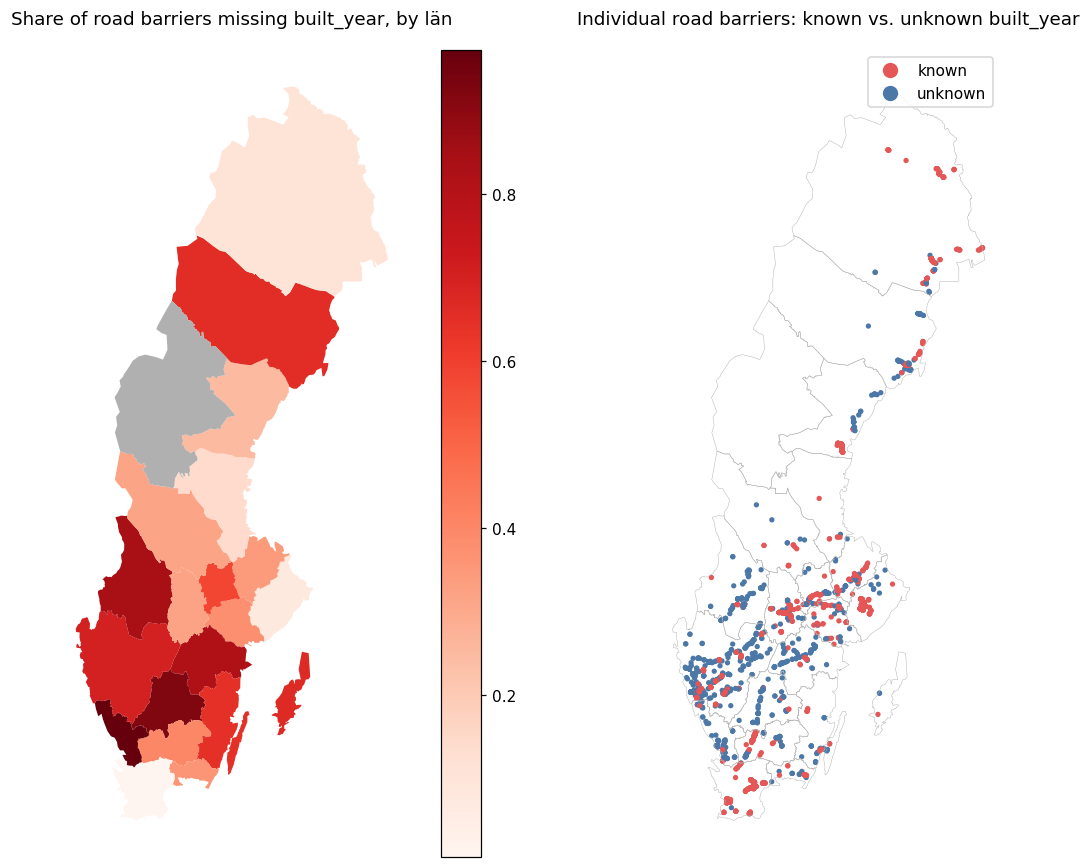

In [9]:
lan_geom = deso[["lanskod", "geometry"]].dissolve(by="lanskod").reset_index().merge(by_lan, on="lanskod", how="left")

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
lan_geom.plot(column="share_missing", cmap="Reds", legend=True, ax=axes[0],
              missing_kwds={"color": GREY, "label": "no road barriers"})
axes[0].set_title("Share of road barriers missing built_year, by län")
axes[0].set_axis_off()

road_pts.plot(ax=axes[1], column=road_pts["built_year"].notna().map({True: "known", False: "unknown"}),
              categorical=True, legend=True, markersize=6,
              cmap=plt.matplotlib.colors.ListedColormap([RED, BLUE]))
lan_geom.boundary.plot(ax=axes[1], color=GREY, linewidth=0.3)
axes[1].set_title("Individual road barriers: known vs. unknown built_year")
axes[1].set_axis_off()
plt.tight_layout()
plt.show()


In [10]:
# Is the geographic pattern really the 2006-01-01 cluster specifically, or
# just overall data quality varying by län for other reasons too? Split
# the two apart directly rather than assuming.
epoch_by_lan = by_area[by_area["valid_from"] == pd.Timestamp("2006-01-01")].groupby("lanskod").size()
total_by_lan = by_area.groupby("lanskod").size()
epoch_share = (epoch_by_lan / total_by_lan).reindex(total_by_lan.index)
compare = pd.DataFrame({
    "lan_namn": total_by_lan.index.map(LAN_NAMES),
    "n_total": total_by_lan,
    "share_missing_overall": by_lan["share_missing"],
    "share_from_2006_cluster": epoch_share,
}).sort_values("share_missing_overall", ascending=False)
print(compare)


                lan_namn  n_total  share_missing_overall  share_from_2006_cluster
lanskod                                                                          
13               Halland      145               0.972414                 0.765517
06             Jönköping       78               0.923077                 0.910256
17              Värmland       96                0.84375                 0.833333
05          Östergötland       83               0.819277                 0.819277
14       Västra Götaland      524               0.704198                 0.671756
09               Gotland        3               0.666667                      NaN
24          Västerbotten      119               0.655462                 0.428571
08                Kalmar       45               0.644444                 0.644444
19           Västmanland      105               0.580952                 0.666667
07             Kronoberg      102               0.401961                 0.333333
04          Söde

In [11]:
# The national 90% missing-rate for the 2006 cluster (§ above) might not
# hold uniformly by region -- check the cluster's OWN missing rate
# separately per län, not just its size, before telling one national
# story about it.
by_area["is_2006_cluster"] = by_area["valid_from"] == pd.Timestamp("2006-01-01")
cross = by_area.groupby(["lanskod", "is_2006_cluster"])["built_year"].agg(n="size", n_missing=lambda s: s.isna().sum())
cross["missing_rate"] = cross["n_missing"] / cross["n"]
cross = cross.reset_index()
cross["lan_namn"] = cross["lanskod"].map(LAN_NAMES)
print(cross.sort_values(["lan_namn", "is_2006_cluster"])[["lan_namn", "is_2006_cluster", "n", "missing_rate"]]
      .to_string(index=False))


       lan_namn  is_2006_cluster   n  missing_rate
       Blekinge            False  21      0.142857
       Blekinge             True   7           1.0
        Dalarna            False  19      0.315789
        Gotland            False   3      0.666667
      Gävleborg            False   7      0.142857
        Halland            False  34      0.882353
        Halland             True 111           1.0
      Jönköping            False   7      0.142857
      Jönköping             True  71           1.0
         Kalmar            False  16           0.0
         Kalmar             True  29           1.0
      Kronoberg            False  68      0.102941
      Kronoberg             True  34           1.0
     Norrbotten            False 125          0.04
     Norrbotten             True  10           1.0
          Skåne            False 171      0.005848
      Stockholm            False  94      0.074468
   Södermanland            False  10           0.1
   Södermanland             Tru

**A real, strong geographic pattern — checked at the (län x cluster)
level directly, not inferred from one aggregate table.** Two separable
findings, not one:

1. **The 2006-01-01 cluster's own missing rate varies by region too, not
   just its size.** In most län where it appears (Halland, Jönköping,
   Kalmar, Kronoberg, Norrbotten, Värmland, Västerbotten, Västra
   Götaland, Östergötland, Blekinge) it's ~100% missing — but in
   **Södermanland it's only 42.9% missing and in Uppsala only 35.4%**,
   both clearly different from the near-universal pattern everywhere
   else. That reads as some regional offices having gone back and
   backfilled `built_year` for their share of the same 2006 migration
   batch, others never having done so — a real difference in regional
   data-quality follow-up, not just in whether the batch landed there.
2. **A second, separate source of missingness exists outside the 2006
   cluster entirely**: Gotland (66.7% missing, n=3), Västerbotten's own
   non-cluster barriers (39.7%), Uppsala's non-cluster barriers (32.6%),
   Dalarna (31.6%, no cluster presence at all), Västernorrland (24.8%,
   no cluster presence at all). This isn't explained by the bulk-import
   story and isn't investigated further here.
3. **Genuinely clean**: Skåne (0.6%) and Stockholm (7.4%) are low with
   or without the cluster — not "avoided one bad batch," their barrier
   records are more complete generally.

**Reading, not confirmed against a primary source**: (1) is consistent
with Trafikverket's regional-office structure (asset management is
organized by geographic region) doing different amounts of backfill
work on the same national migration batch. (2) has no obvious
explanation from this data alone and would need a different check
(e.g. barrier age/type composition per region) before guessing further.

Rail's own missing rate (26.6%, computed above) is not broken down by
region here — the road pattern was the one worth chasing since it drives
`timing_unknown` for the larger, more heavily-treated barrier kind.


### 3.4 Physical dimensions


In [12]:
dims_road = road_barriers[["height_m", "extent_length_m"]].astype(float)
print("road — dimension summary:")
print(dims_road.describe(percentiles=[.1, .25, .5, .75, .9]).round(2).T[["min", "10%", "50%", "90%", "max"]])

dims_rail = rail_barriers[["height_above_rail_top_m", "distance_from_track_center_m", "extent_length_m"]].astype(float)
print("\nrail — dimension summary:")
print(dims_rail.describe(percentiles=[.1, .25, .5, .75, .9]).round(2).T[["min", "10%", "50%", "90%", "max"]])


road — dimension summary:
                 min    10%    50%    90%      max
height_m         0.0   0.00   0.00    3.0   102.90
extent_length_m  1.0  15.19  71.94  268.8  1211.77

rail — dimension summary:
                              min   10%     50%     90%      max
height_above_rail_top_m       0.0  1.00    2.61  999.00   999.00
distance_from_track_center_m  0.0  3.68  999.00  999.00   999.00
extent_length_m               0.0  9.47   79.49  367.33  2042.38


Road's dimensions look sane (heights 0–~103 m *sic* — likely a few
digitizing outliers, lengths 1–1,212 m). Rail's `height_above_rail_top_m`
and `distance_from_track_center_m` don't: both max out at exactly `999`,
far outside the plausible range implied by their own 10th/90th
percentiles. That shape — a hard ceiling at a round number, unrelated to
the rest of the distribution — is the same signature `built_year`'s `1900`
sentinel had before `preprocess.py` nulled it out (§4). Checked directly
below rather than assumed from the shape alone.


In [13]:
for col in ["height_above_rail_top_m", "distance_from_track_center_m"]:
    n999 = (rail_barriers[col] == 999).sum()
    print(f"{col}: {n999:,} / {len(rail_barriers):,} ({n999 / len(rail_barriers):.1%}) rows == 999")


height_above_rail_top_m: 292 / 1,829 (16.0%) rows == 999
distance_from_track_center_m: 1,033 / 1,829 (56.5%) rows == 999


**A second, previously-undocumented sentinel — not yet fixed.** 16% of
`height_above_rail_top_m` and 56% of `distance_from_track_center_m` carry
`999` as a "not recorded" placeholder, exactly analogous to `built_year`'s
`1900`/`0` sentinels — but `preprocess.py`'s `BUILT_YEAR_SENTINEL` dict
only covers `built_year`; these two columns are passed through as
plausible-looking numeric data. **Any summary statistic above that touches
`distance_from_track_center_m` in particular is contaminated by this** —
its mean (567 m) and every percentile at or above the median are pulled
toward 999 by construction. Flagged here as a real gap, not fixed in this
notebook (see [`docs/data/sweden/schools/README.md`](../../../docs/data/sweden/schools/README.md)
if this is picked up as a follow-on task).


### 3.5 Geography: statewide map


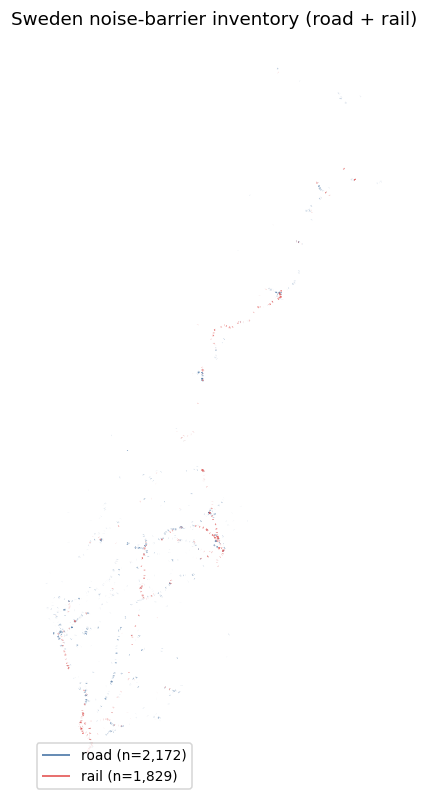

In [14]:
fig, ax = plt.subplots(figsize=(6, 9))
road_barriers.plot(ax=ax, color=BLUE, linewidth=1.1, label=f"road (n={len(road_barriers):,})")
rail_barriers.plot(ax=ax, color=RED, linewidth=1.1, label=f"rail (n={len(rail_barriers):,})")
ax.set_title("Sweden noise-barrier inventory (road + rail)")
ax.legend(loc="lower left", fontsize=9)
ax.set_axis_off()
plt.show()


## 4. Cleaning

`noise_barriers/preprocess.py` (not this notebook) applies the cleaning
rules to the raw GeoPackage export:

1. **Reproject** to EPSG:4326 (raw delivery is SWEREF99 TM, EPSG:3006).
2. **Rename** every raw Swedish column to its English name (§2's field
   dictionary).
3. **Translate coded values** for `side`, `absorbent`, `owner`,
   `material_type`/`barrier_type`, `foundation_type`, and the maintenance
   fields — Swedish text → English, unknown markers (`Okänt`/`?`) → `None`.
4. **Null the `built_year` sentinel** — `1900` for road, `0` for rail —
   confirmed empirically while building `schools/assemble.py` (51% of raw
   road records carried `1900`).
5. **Coerce numeric columns** and parse `valid_from`/`valid_to` dates
   (`99991231` → `NaT`, meaning "still valid").

Verified live below, against the real processed files, rather than just
reading the module's own comments.


In [15]:
print("road built_year == 1900 remaining:", int((road_barriers["built_year"] == 1900).sum()))
print("rail built_year == 0 remaining:", int((rail_barriers["built_year"] == 0).sum()))

leftover_swedish = {
    "road side": set(road_barriers["side"].dropna().unique()) - {"right", "left", "both_sides", "center"},
    "rail side": set(rail_barriers["side"].dropna().unique()) - {"right", "left", "both_sides", "center"},
    "road owner": set(road_barriers["owner"].dropna().unique())
        - {"Swedish Transport Administration", "municipality", "other landowners", "other"},
    "road material_type": set(road_barriers["material_type"].dropna().unique())
        - {"wood", "earth berm", "glass_or_plexiglass", "plastic", "other", "stone_or_brick", "concrete", "metal", "gabion"},
}
print("\nvalue-translation columns with any leftover (untranslated) value:")
for name, leftover in leftover_swedish.items():
    print(f"  {name}: {leftover or '(none)'}")


road built_year == 1900 remaining: 0
rail built_year == 0 remaining: 0

value-translation columns with any leftover (untranslated) value:
  road side: (none)
  rail side: (none)
  road owner: (none)
  road material_type: (none)


Both sentinel fixes and every checked value-translation are clean —
confirmed no leftover raw values, not assumed. The one real cleaning gap
this notebook found (§3.4's `999` sentinel in two rail dimension columns)
is *not* covered by the list above; it would need its own entry in
`BUILT_YEAR_SENTINEL`-style logic (renamed to something more general, since
it's no longer just about `built_year`) to fix.


## 5. School locations


In [16]:
schools_gdf = gpd.read_file(SCHOOLS / "processed" / "schools.geojson")
print(f"{len(schools_gdf):,} school-unit records")
print("geocoded (has geometry):", schools_gdf.geometry.notna().sum(), f"({schools_gdf.geometry.notna().mean():.1%})")
schools_gdf[["skolenhetskod", "namn", "kommun_namn", "huvudman_typ"]].head()


10,648 school-unit records
geocoded (has geometry): 9520 (89.4%)


,skolenhetskod,namn,kommun_namn,huvudman_typ
0,10001993,Kunskapshusets Resursskola,Eslöv,Kommun
1,10017830,Nytorpsskolan,Surahammar,Kommun
2,10023937,Mimerskolan,Sundsvall,Enskild
3,10035236,Söderbymalmsskolan,Haninge,Kommun
4,10052155,Kunskapsskolan Väst,Norrköping,Enskild


## 6. Matching schools to barriers

`schools/assemble.py`'s algorithms 1–2 already compute this match (nearest
distance, `ever_treated`, `timing_unknown`) for the full pipeline. Rather
than reprototyping a second, from-scratch nearest-distance computation
here (as [`florida/barriers.ipynb`](../florida/barriers.ipynb) does, since
Florida's notebook predates a school-level matching step of its own), this
section loads and validates the *real* persisted output directly — this
notebook already loads the real processed barrier files everywhere else,
so the point-distance match should be no exception.


In [17]:
road_rollup = pd.read_parquet(SCHOOLS / "assembled" / "schools_road_rollup.parquet")
rail_rollup = pd.read_parquet(SCHOOLS / "assembled" / "schools_rail_rollup.parquet")

for name, rollup in [("road", road_rollup), ("rail", rail_rollup)]:
    print(f"{name}: {rollup['ever_treated'].sum():,} ever-treated schools (point-only), "
          f"median nearest_dist_m={rollup['nearest_dist_m'].median():.0f}, "
          f"timing_unknown={rollup['timing_unknown'].sum():,}")


road: 1,251 ever-treated schools (point-only), median nearest_dist_m=3803, timing_unknown=845
rail: 1,454 ever-treated schools (point-only), median nearest_dist_m=5561, timing_unknown=797


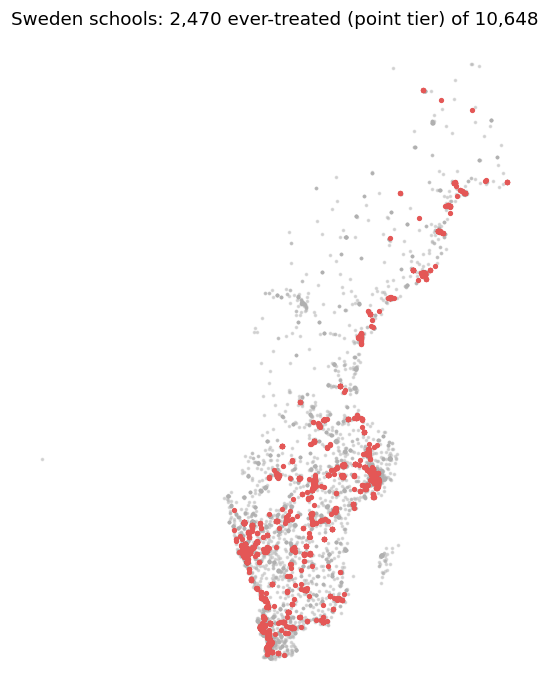

In [18]:
fig, ax = plt.subplots(figsize=(6, 9))
schools_gdf.plot(ax=ax, markersize=2, color=GREY, alpha=0.4, label="never-treated")
treated_codes = set(road_rollup.loc[road_rollup["ever_treated"], "skolenhetskod"]) | set(
    rail_rollup.loc[rail_rollup["ever_treated"], "skolenhetskod"])
treated = schools_gdf[schools_gdf["skolenhetskod"].isin(treated_codes)]
treated.plot(ax=ax, markersize=6, color=RED, label="ever-treated (point, road or rail)")
ax.set_title(f"Sweden schools: {len(treated):,} ever-treated (point tier) of {len(schools_gdf):,}")
ax.set_axis_off()
plt.show()


## 7. Persist outputs

Nothing new is written here. The clean barrier layers are already the
`noise-barriers preprocess` pipeline step
(`src/regions/sweden/sources/noise_barriers/preprocess.py` →
`data/sweden/noise_barriers/processed/{road,rail}_noise_barriers.parquet`),
and the point-distance school match is already `schools assemble`'s
algorithms 1–2 (`data/sweden/schools/assembled/schools_{road,rail}_rollup.parquet`).
This notebook only reads and validates both.


## Notes & caveats

- **Coverage bias.** This is a Trafikverket state-road/rail facility
  register, not a census of every acoustic barrier — municipal or private
  screening walls are not part of either export. Treat "distance to
  nearest wall" as "distance to nearest *state* road/rail wall".
- **Live snapshot only, no lifecycle field.** Every row is `is_current`;
  unlike Florida's FDOT inventory there's no way to see a barrier that was
  planned, recommended, or removed — this data answers "what stands today"
  only.
- **The raw `.gpkg` filenames are swapped relative to their content** (§1):
  `highway_noise_barriers.gpkg` is actually rail data, `railway_noise_barriers.gpkg`
  is actually road data — confirmed via schema fields that only exist on
  one side. `noise_barriers/preprocess.py` is unaffected (it resolves its
  input by delivery-info content, not filename), but anyone loading the
  raw files directly by name will silently get the wrong kind.
- **A second `999`-sentinel gap, found here and not yet fixed**: rail's
  `height_above_rail_top_m` (16%) and `distance_from_track_center_m` (56%)
  carry an unhandled "not recorded" placeholder, unlike `built_year`,
  which `preprocess.py` already nulls out per dataset kind (§4).
- **Missing `built_year` has a real, strong geographic pattern** (§3.3): a
  2006-01-01 bulk-import cluster (1,064 of 2,172 road barriers, 90%
  missing `built_year`) is concentrated in specific län and completely
  absent from others — consistent with a region-specific data-migration
  artifact, though not confirmed against Trafikverket's own regional
  boundaries directly.
- **The road-network-aware `same_route`/`same_side` tiers** (algorithms
  3–5), the `same_side` bug, and the side-attribute refutation are verified
  against real persisted output in [`schools.ipynb`](schools.ipynb) — not
  reprototyped here.
